# DNA Dataset for DNA Sequencing
- The encoding in this part is different as it uses permute encoding. That is permute and bundle DNA sequences per position.
- Here we investigate similar trends to which encoding scheme provides the highest accuracy.

In [1]:
# Parameters
import os
import sys
import numpy as np

# Path directories
curr_dir = os.getcwd()
lib_path = curr_dir + "/../../lib"
extract_path = curr_dir + "/../../extract_data"
data_path = curr_dir + "/../../data"
dir_bin_data = data_path + "/dna"

# Appending other paths for libraries
sys.path.append(lib_path)
sys.path.append(extract_path)

import vsa
import figs
from extract_data_util import download_and_extract, read_data, split_data

## Data Extraction

In [2]:
url = "https://github.com/rgantonio/chronomatica/releases/download/dna_dataset_v1.0/chronomatica_dna.tar.gz"

download_and_extract(
    url=url,
    out_dir=data_path,
    delete_archive=True,
)

# Set class list
class_list = [0,1,2]

# Read data
X_data = read_data(class_list, dir_bin_data)

# Train and test split
train_test_split = 0.6
train_valid_split = 0.75

X_train_set, X_test_set = split_data(X_data, class_list, split_percent=train_test_split)
X_train_set_src, X_valid_set = split_data(X_train_set, class_list, split_percent=train_valid_split)

Extracting...
Deleted archive: chronomatica_dna.tar.gz
Extraction complete!


Splitting data: 100%|██████████| 3/3 [00:00<00:00, 3320.91it/s]


## VSA Model
- VSA model uses permute encoding. Practically permute $i$ times depending on the number of sequences and bundle each element.

$$ \mathcal{hv}_{\textrm{enc}} = \sum_{i=0}^{N_\textrm{seq}} \rho^i \left(\mathcal{hv}_{\textrm{DNA-base}}[i] \right) $$

In [6]:
class dnaVSA(vsa.ModelVSA):
    def encode(self, item_data):
        # Feature length
        item_len = len(item_data)
        encoded_vec = np.zeros(self.hv_size)

        # Iterate through different item
        for i in range(item_len):
            # Fetch and permute i-times
            encoded_vec += vsa.hv_perm(self.ortho_im[item_data[i]], i)
        # Threshold for binarization
        threshold = item_len // 2
        # Binarization
        if self.binarize_encode:
            encoded_vec = vsa.binarize_hv(encoded_vec, threshold, self.hv_type)
        return encoded_vec

# Training, Retraining, and Testing
- This time we add a switch to collect the accuracies in a list varying the HV dimensions

In [9]:
# Parameters
hv_dim_set = [512, 1024, 2048, 4096, 8192]
hv_dim_set_len = len(hv_dim_set)
accuracy_list = np.zeros(hv_dim_set_len)

In [13]:
for hv_dim in hv_dim_set:
    print(f"Running HV Dimension: {hv_dim}")
    # Create the VSA model with target parameters
    dna_model = dnaVSA(
        hv_size = hv_dim,
        class_list = class_list,
    )

    # CHANGE ME FOR EXPERIMENTATION:
    # Add the following to binarize the encoded value
    dna_model.binarize_encode = False
    # Add the following to binarize the AM
    dna_model.binarize_am = False

    # For debug parameters only
    dna_model.tqdm_train_mode = False
    dna_model.tqdm_retrain_mode = False
    dna_model.tqdm_test_mode = False

    # Train the model
    dna_model.train_model(X_train_set_src)

    # Retraining the model
    dna_model.retrain_model(X_valid_set)

    # Test the model
    dna_model.test_model(X_test_set)

    # Save accuracy
    accuracy_list[hv_dim_set.index(hv_dim)] = dna_model.model_accuracy

for i in range(len(accuracy_list)):
    accuracy_list[i] = accuracy_list[i]*100

accuracy_list

Running HV Dimension: 512
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 1024
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 2048
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 4096
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 8192
Training complete!
Retraining complete!
Testing complete!


array([87.93103448, 89.4200627 , 92.00626959, 90.59561129, 91.37931034])

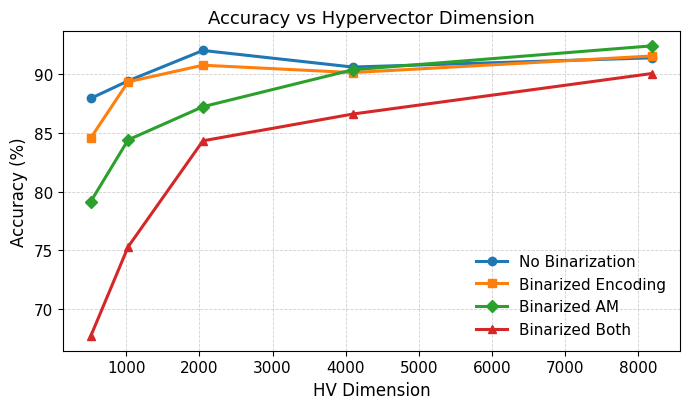

In [14]:
acc = [
    [87.93103448, 89.4200627 , 92.00626959, 90.59561129, 91.37931034],
    [84.56112853, 89.34169279, 90.7523511 , 90.12539185, 91.53605016],
    [79.15360502, 84.40438871, 87.22570533, 90.36050157, 92.39811912],
    [67.71159875, 75.31347962, 84.32601881, 86.59874608, 90.04702194],
]

hv_dim = [512, 1024, 2048, 4096, 8192]

legend = ['No Binarization', 'Binarized Encoding', 'Binarized AM', 'Binarized Both']
x_label = 'HV Dimension'
y_label = 'Accuracy (%)'
title = 'Accuracy vs Hypervector Dimension'

figs.multiLinePlot(
    x_data=hv_dim,
    y_data_list=acc,
    legend_list=legend,
    x_label=x_label,
    y_label=y_label,
    title=title,
).plot_fig()

In [15]:
dna_model.print_model_stats()


-----------------
Model Statistics:
-----------------
HV Size: 8192
HV Type: bipolar
Number of Orthogonal IMs: 1024
Number of Continuous IMs: 21
Number of Classes: 3
Binarize Encode: False
Binarize AM: False
Class 0 Accuracy: 94.79%
Class 1 Accuracy: 95.44%
Class 2 Accuracy: 87.92%
Overall Accuracy: 91.38%


# Some Conclusions
- The conclusion is the same, non-binary gives the best accuracy across dimensions.
- However, it might be wise to use binary encoding but keep AM non-binarized always.